## Using numpy to cluster data

### Getting the data

In [55]:
%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl (8.0 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl (36.5 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ------------------


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import numpy as np

In [4]:
def get_data():
    data_set_1_file = "data/cluster_data_set_2d.csv"
    data_labels_1_file = "data/cluster_data_set_2d_labels.csv"
    test_data_set_1_file = "data/cluster_test_data_set_2d.csv"
    test_data_labels_1_file = "data/cluster_test_data_set_2d_labels.csv"
    data_set_1 = np.loadtxt(data_set_1_file, delimiter=',', skiprows=1)
    data_labels_1 = np.loadtxt(data_labels_1_file, delimiter=',', skiprows=1, )
    test_data_set_1 = np.loadtxt(test_data_set_1_file, delimiter=',', skiprows=1)
    test_data_labels_1 = np.loadtxt(test_data_labels_1_file, delimiter=',', skiprows=1)
    return data_set_1,data_labels_1, test_data_set_1, test_data_labels_1

In [5]:
data_set_1,data_labels_1, test_data_set_1, test_data_labels_1=get_data()

In [6]:
from numpy_clustering_functions import leader_clustering

In [7]:
def perform_leader_clustering(data_set, cluster_results):
    # Perform leader clustering
    try:
        for threshold in np.array([0.8, 1.4, 2.0, 3.0, 4.0]):
            print(f"Clustering with threshold {threshold}")
            c1, l1 = leader_clustering(data_set, threshold)
            print(f"Clustering with threshold {threshold} completed")
            print(f"Number of clusters: {len(np.unique(l1))}")
            r = {'type': 'leader', 'parameter': threshold,'num_of_clusters':len(c1), 'clusters': c1.copy(), 'labels': l1.copy()}
            cluster_results.append(r)
        return cluster_results
    except Exception as e:
        print("Unable to perform leader clustering", e)

In [8]:
cluster_results=[]
cluster_results=perform_leader_clustering(data_set_1, cluster_results)

Clustering with threshold 0.8
Clustering with threshold 0.8 completed
Number of clusters: 22
Clustering with threshold 1.4
Clustering with threshold 1.4 completed
Number of clusters: 11
Clustering with threshold 2.0
Clustering with threshold 2.0 completed
Number of clusters: 6
Clustering with threshold 3.0
Clustering with threshold 3.0 completed
Number of clusters: 3
Clustering with threshold 4.0
Clustering with threshold 4.0 completed
Number of clusters: 2


In [9]:
from numpy_clustering_functions import kmeans_clustering

In [10]:
def perform_k_means_clustering(data_set_1, clluster_results):
    # perform k-means clustering
    try:
        for n_clusters in np.array([2, 3, 4, 5, 6]):
            print(f"Clustering with {n_clusters} clusters")
            c1, l1 = kmeans_clustering(data_set_1, n_clusters)
            print(f"Clustering with {n_clusters} clusters completed")
            print(f"Number of clusters: {len(np.unique(l1))}")
            r = {'type': 'k-means', 'parameter': n_clusters,'num_of_clusters':n_clusters, 'clusters': c1.copy(), 'labels': l1.copy()}
            cluster_results.append(r)
        return cluster_results
    except Exception as e:
        print("Unable to perform k-means clustering", e)

In [11]:
cluster_results=perform_k_means_clustering(data_set_1, cluster_results)

Clustering with 2 clusters
Clustering with 2 clusters completed
Number of clusters: 2
Clustering with 3 clusters
Clustering with 3 clusters completed
Number of clusters: 3
Clustering with 4 clusters
Clustering with 4 clusters completed
Number of clusters: 4
Clustering with 5 clusters
Clustering with 5 clusters completed
Number of clusters: 5
Clustering with 6 clusters
Clustering with 6 clusters completed
Number of clusters: 6


In [12]:
from numpy_clustering_functions import intra_cluster_distance, inter_cluster_distance

In [13]:
def check_performance(cluster_results):
    for c in cluster_results:
        c['intra'] = intra_cluster_distance(data_set_1, c['labels'], c['clusters'])
        c['inter'] = inter_cluster_distance(data_set_1, c['labels'], c['clusters'])
    performance_ready = True if len(cluster_results) == 10 else False
    for i,c in enumerate(cluster_results):
        if 'intra' not in c.keys() or 'inter' not in c.keys():
            print(f"The clustering result {c['type']}/{c['parameter']} does not contain the expected fields.")
            performance_ready = False
        else:
            print(f"id={i} number_of_clusters={c['num_of_clusters']}: The clustering result {c['type']}/{c['parameter']} - intra = {c['intra']} - inter = {c['inter']}")

    if not performance_ready:
        print("Not all clustering results contain the expected fields. Please check the implementation.")


In [14]:
check_performance(cluster_results)

id=0 number_of_clusters=22: The clustering result leader/0.8 - intra = [0.40274737 0.39318375] - inter = 6.950679203184295
id=1 number_of_clusters=11: The clustering result leader/1.4 - intra = [0.69137754 0.70337268] - inter = 7.041770957244185
id=2 number_of_clusters=6: The clustering result leader/2.0 - intra = [1.00921588 0.79722517] - inter = 7.2805364223114974
id=3 number_of_clusters=3: The clustering result leader/3.0 - intra = [1.3301447 1.2934942] - inter = 9.265631632918506
id=4 number_of_clusters=2: The clustering result leader/4.0 - intra = [1.32041756 2.02263503] - inter = 13.653398925599891
id=5 number_of_clusters=2: The clustering result k-means/2 - intra = [0.85544595 1.59464061] - inter = 10.637643280592764
id=6 number_of_clusters=3: The clustering result k-means/3 - intra = [0.84380421 0.72423708] - inter = 6.958514535119535
id=7 number_of_clusters=4: The clustering result k-means/4 - intra = [0.82999222 0.6103138 ] - inter = 7.094087802868026
id=8 number_of_clusters=

In [15]:
from numpy_clustering_functions import intra_cluster_distance, inter_cluster_distance, assign_data_to_cluster

In [16]:
def select_cluster_from_cluster_results_by_id(id, cluster_results, test_data_set_1):
    selected_cluster = cluster_results[id]
    test_cluster_result = {
        'type': selected_cluster['type'],
        'parameter': selected_cluster['parameter'],
        'clusters': selected_cluster['clusters'].copy()
    }
    test_cluster_result['labels'] = assign_data_to_cluster(test_data_set_1, selected_cluster['clusters'])
    test_cluster_result['intra'] = intra_cluster_distance(test_data_set_1, test_cluster_result['labels'], selected_cluster['clusters'])
    test_cluster_result['inter'] = inter_cluster_distance(test_data_set_1, test_cluster_result['labels'], selected_cluster['clusters'])
    return test_cluster_result, selected_cluster


In [17]:
test_cluster_result, selected_cluster=select_cluster_from_cluster_results_by_id(6,cluster_results, test_data_set_1)
other_test_cluster_result, other_selected_cluster=select_cluster_from_cluster_results_by_id(7,cluster_results, test_data_set_1)

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

In [71]:
def legend_without_duplicate_labels1(ax):
    handles, labels = ax.get_legend_handles_labels()
    unique = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]]
    ax.legend(*zip(*unique))

In [68]:
def legend_without_duplicate_labels(figure):
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    figure.legend(by_label.values(), by_label.keys(), loc='lower right')

In [ ]:
def get_mapping(array1, array2):
    mapping={}
    print("shape uniquz")
    print(np.unique(array1).shape[0])
    ar1_unique_biggest=False
    if np.unique(array1).shape>np.unique(array2).shape:
        ar1_unique_biggest=True
    else:
        ar1_unique_biggest=False

    for el_ar1, el_ar2 in zip(array1,array2):
        if ar1_unique_biggest:
            mapping[el_ar1]=el_ar2
        else:
            mapping[el_ar2]=el_ar1
    return mapping

def apply_mapping(array, mapping):
    mapped_list=[]
    for ar_el in array:
        mapped_list.append(mapping[ar_el])
    return np.asarray(mapped_list)

def group(data, cluster_ids):
    print(data.shape)
    print(cluster_ids.shape)
    data = np.concatenate((cluster_ids[:, np.newaxis], data), axis=1)
    data = data[data[:, 0].argsort()]
    clusters = np.array_split(data[:, :], np.unique(data[:, 0], return_index=True)[1][1:])
    #print("clusters")
    #print(clusters)
    return clusters

    

In [157]:
def visualize_cluster(selected_cluster,ax, data_set, data_labels):
    #df_centers = pd.DataFrame(selected_cluster['clusters'], columns=['x','y'])
    #df_clustered = pd.concat([pd.DataFrame(data_set_1, columns=['x','y']), pd.DataFrame(selected_cluster['labels'], columns=['cluster'])], axis=1)
    #ax.scatter(df_clustered, marker='o')
    #print(selected_cluster['clusters'])
    #cluster_labels = data_labels_1

    cluster_labels=selected_cluster['labels']
    print(cluster_labels)
    colormap = np.array(['r', 'g', 'b','y'])
    colormap1 = np.array(['c', 'm', 'y','orange'])

    cluster_labels_test=data_labels.astype(np.int32)
    mapping=get_mapping(cluster_labels_test, cluster_labels)
    print(mapping)
    cluster_labels=apply_mapping(cluster_labels,mapping)
    print(np.unique(cluster_labels))

    ari_score = adjusted_rand_score(cluster_labels, cluster_labels_test)
    nmi_score = normalized_mutual_info_score(cluster_labels, cluster_labels_test)

    print(f"ARI Score: {ari_score}")
    print(f"NMI Score: {nmi_score}")

    target_clusters=group(data_set, cluster_labels)
    predicted_clusters=group(data_set, cluster_labels_test)

    for ar in target_clusters:
        ax.scatter(ar[:,1],ar[:,2], c=colormap[ar[:,0].astype(np.int32)], marker='o', alpha=0.5, label=f"target {ar[0,0]}")

    for ar in predicted_clusters:
        ax.scatter(ar[:,1],ar[:,2], c=colormap[ar[:,0].astype(np.int32)], marker='x', alpha=0.5, label=f"predicted {ar[0,0]}")

    ax.scatter(selected_cluster['clusters'][:,0],selected_cluster['clusters'][:,1], marker='^', color='black', )
    ax.legend()
    return ax

[2 0 2 1 2 0 2 2 1 0 2 2 2 1 1 2 2 0 1 2 1 1 0 1 2 2 1 0 0 0 2 1 2 0 1 0 1
 2 0 1 0 1 2 0 1 0 0 0 0 2 1 0 1 0 2 0 2 1 1 1 0 0 2 0 2 2 1 2 0 0 0 0 0 1
 0 0 1 1 1 1 2 2 2 2 1 2 0 1 0 2 2 0 2 0 2 2 2 0 0 1 1 2 1 1 2 0 2 0 2 2 1
 1 2 1 0 1 0 2 0 1 2 0 1 0 0 2 1 1 0 0 2 1 1 0 2 0 1 1 2 0 0 1 0 2 1 1 2 2
 2 0 1 1 1 1 2 0 0 2 0 2 1 1 0 1 1 2 0 2 0 1 1 1 0 2 2 1 2 1 2 0]
shape uniquz
3
{np.int64(2): np.int32(1), np.int64(0): np.int32(3), np.int64(1): np.int32(2)}
[1 2 3]
ARI Score: 1.0
NMI Score: 1.0
(180, 2)
(180,)
(180, 2)
(180,)
[0 2 0 1 0 2 0 0 1 3 0 0 0 1 1 0 0 2 3 0 3 3 2 3 0 0 1 2 2 2 0 3 0 2 3 2 3
 0 2 1 2 3 0 2 1 2 3 2 2 0 1 2 1 2 0 2 0 3 1 1 2 2 0 2 0 0 1 0 2 2 2 2 2 1
 2 2 3 3 3 1 0 0 0 0 3 0 2 1 2 0 0 2 0 2 0 0 0 2 2 1 3 0 3 1 0 2 0 2 0 0 3
 1 0 3 2 1 2 0 2 3 0 2 3 2 2 0 3 3 2 2 0 3 3 2 0 2 1 1 0 2 2 3 2 0 3 1 0 0
 0 2 3 1 3 1 0 2 2 0 2 0 3 1 2 1 3 0 2 0 2 1 1 1 2 0 0 3 0 1 0 2]
shape uniquz
3
{np.int64(0): np.int32(1), np.int64(2): np.int32(3), np.int64(1): np.int32(2), np.int64(3

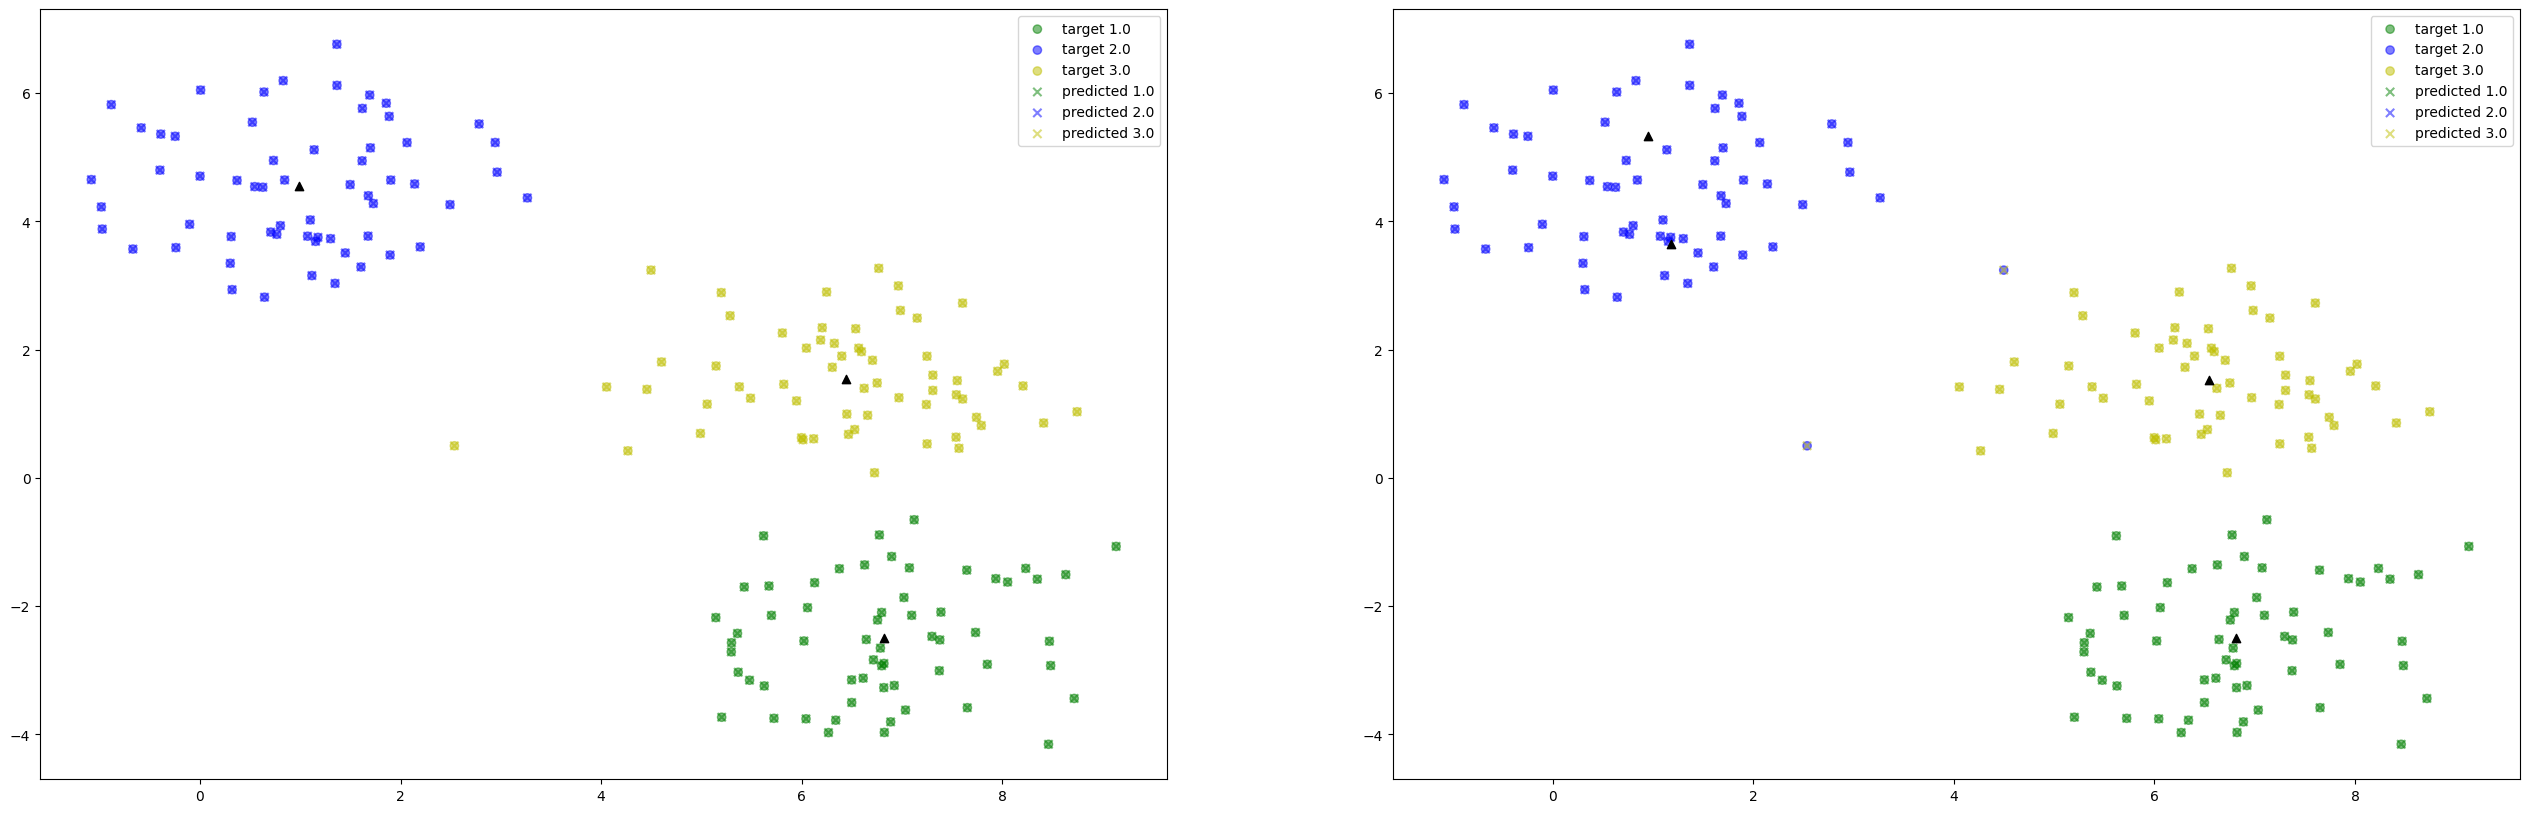

In [158]:
fig, ax=plt.subplots(1,2, figsize=[32,10])
ax[0]=visualize_cluster(selected_cluster,ax[0],data_set_1, data_labels_1)

ax[1]=visualize_cluster(other_selected_cluster,ax[1],data_set_1, data_labels_1)
#legend_without_duplicate_labels(fig)




In [ ]:
fig, ax=plt.subplots(1,2, figsize=[32,10])
ax[0]=visualize_cluster(selected_cluster,ax[0],data_set_1, test_data_labels_1)

ax[1]=visualize_cluster(other_selected_cluster,ax[1],data_set_1, test_data_labels_1)

In [ ]:
def visualize_cluster(selected_cluster, test_cluster_result):
    if selected_cluster is None or test_cluster_result is None:
        print("No selected clustering result found. Skipping visualisation steps.")
    else:
        print(f"Selected clustering result: {test_cluster_result}")

    df_centers = pd.DataFrame(selected_cluster['clusters'], columns=['x','y'], index=[0,1,2])
    #df_train = pd.concat([pd.DataFrame(data_set_1, columns=['x','y']), pd.DataFrame(data_labels_1, columns=['cluster'])], axis=1)
    df_clustered = pd.concat([pd.DataFrame(data_set_1, columns=['x','y']), pd.DataFrame(selected_cluster['labels'], columns=['cluster'])], axis=1)
    #sns.scatterplot(data=df_train, x='x', y='y', hue='cluster' , palette="tab10", alpha=0.4)
    sns.scatterplot(data=df_clustered, x='x', y='y', hue='cluster' , palette="tab10", marker='x')
    sns.scatterplot(data=df_centers, x='x', y='y', c="k", marker='^', label="cluster center")
    plt.title(f"Clustering data set with {selected_cluster['type']}/{selected_cluster['parameter']}")
    plt.show(block=True)

    df_test_clustered = pd.concat([pd.DataFrame(test_data_set_1, columns=['x','y']), pd.DataFrame(test_cluster_result['labels'], columns=['cluster'])], axis=1)
    df_test = pd.concat([pd.DataFrame(test_data_set_1, columns=['x','y']), pd.DataFrame(test_data_labels_1, columns=['cluster'])], axis=1)
    sns.scatterplot(data=df_test, x='x', y='y', hue='cluster' , palette="tab10", alpha=0.4)
    sns.scatterplot(data=df_test_clustered, x='x', y='y', hue='cluster' , palette="tab10", marker='x')
    sns.scatterplot(data=df_centers, x='x', y='y', c="k", marker='^', label="cluster center")
    plt.title(f"Clustering test set with {selected_cluster['type']}/{selected_cluster['parameter']}")
    plt.show(block=True)

Selected clustering result: {'type': 'k-means', 'parameter': np.int64(3), 'clusters': array([[ 6.69379992, -0.54882609],
       [ 0.91441994,  5.35278759],
       [ 1.32073065,  3.65116043]]), 'labels': array([0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 1,
       2, 0, 0, 0, 0, 1, 1, 2, 2, 0, 1, 0, 0, 1, 2, 0, 2, 0, 0, 2, 0, 0,
       1, 2, 2, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 1, 0, 0, 0, 0]), 'intra': array([0.84159629, 1.33167748]), 'inter': np.float64(8.891281048781318)}


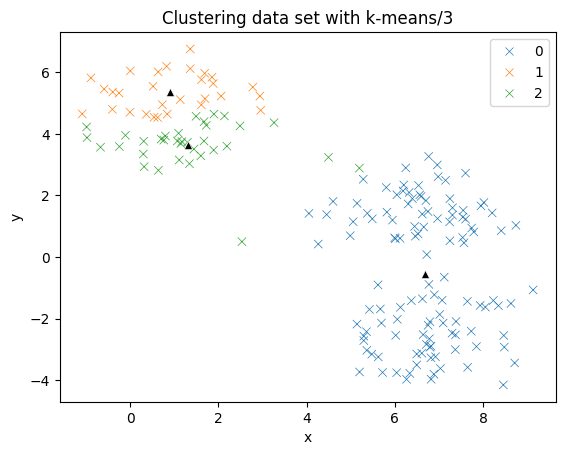

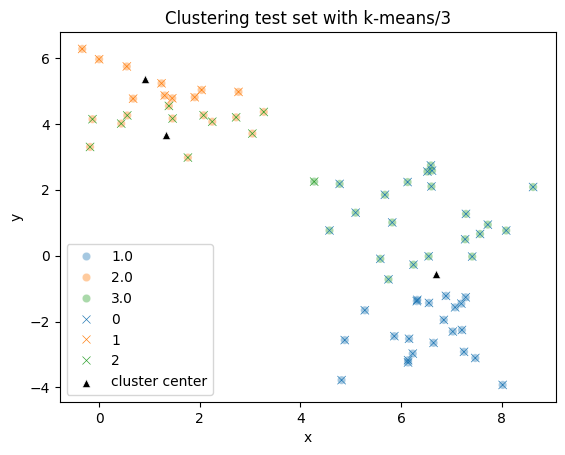

In [ ]:
visualize_cluster(selected_cluster,test_cluster_result)